In [1]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from scipy.special import factorial
from scipy.stats import binned_statistic
from matplotlib.ticker import ScalarFormatter
import sys

In [2]:
sys.path.append(r"C:\Users\xylin\Documents\Researches\multiphonon-direct-detection\StructureFactor1D.py")
from StructureFactor1D import StructureFactor1D
from StructureFactor1D import StructureFactor1D_NIndepDW

In [ ]:
class StructureFactor1DCoherent(StructureFactor1D_NIndepDW):
    ######## Public ########

    def init_recursion(self): 
        print('Processing n = 1...')
        self.sOrder = 1
        # self._s_diag_init()
        self.get_c_offdiag_init()

    def update_s_factor(self):
        '''
        Update the integrated diagonal s factor (both diagonal and off diagonal) using the recursive relation.
        '''
        self.sOrder += 1
        print(f'Processing n = {self.sOrder}...')
        sFactor_diag = self._calc_diag_s_rec()
        self.currIntS_diag = self._integrate_s_diag(sFactor_diag)
    

    def get_binned_s_offdiag(self, xlist, delta_omega):
        pass 

    ######## Helper ########

    def _c_offdiag_init(self,): # l' minus l
        '''
        --------returns------
        currIntC_offdiag: 2d array with shape (# of nu, # of xi)
        '''
        DWfactor =  np.exp(- 2 * self.getDebyeWallerConst()) 
        offdiag_factor = np.exp(1j*(self.q_value*self.latticeConst-2*np.pi* self.nuList[:,np.newaxis]/self.nLattice)* self.l_diff) 
        c_values =  2 * np.pi / self.volume * DWfactor *  (self.q_value**2 /(2*self.mass*self.nLattice)) * offdiag_factor/ self.omegaList[:,np.newaxis]
        self.currIntC_offdiag = self._integrate_c_offdiag(self.omegaList, c_values)


    def _integrate_c_offdiag(self,allowed_omegas, c_offdiag):
        result = binned_statistic(allowed_omegas, c_offdiag.T, statistic="sum",bins=self._DoS_nBins, range=(self._DoS_min_omega, self._DoS_max_omega))
        return result.statistic.T

    def _calc_c_offdiag_rec(self, ):
        offdiag_factor = np.exp(2j*np.pi*self.nuList[:,np.newaxis]*self.l_diff/self.nLattice)
        (self.q_value**2 /(2*self.mass*self.nLattice))/self.sOrder
        # a hell of indicies

    def _integrate_s_off_diag(self):
        self.l_diff
        self.currIntC_offdiag
        # something i havent figure out
        return np.sum(something*(self.couplingConst**2)*2*(self.latticeConst-self.l_diff), axis=1) # i hope axis = 1 is correct


In [ ]:
nus = np.array([1,2,3, 7,8])
xis = np.array([4j,5j, 10j])
arr3 = nus**2
res = nus[:,np.newaxis]*xis/arr3[:,np.newaxis]
binned_statistic(nus, res.T, statistic="sum", bins=2).statistic.T, res.shape, res

array([[0. +7.33333333j, 0. +9.16666667j, 0.+18.33333333j],
       [0. +1.07142857j, 0. +1.33928571j, 0. +2.67857143j]])

In [8]:
multplier = 2
q_value  = multplier*np.sqrt(2*26161e3*8.25e-6)
nLattice = 40
test = StructureFactor1DCoherent(nLattice = nLattice,q_value=q_value, couplingConst=28,)
ini_off_diag = test.get_off_diag_s_init()

Processing n = 1...
Plotting n = 1...
Processing n = 2...
Plotting n = 2...
Processing n = 3...
Plotting n = 3...
Processing n = 4...
Plotting n = 4...
Processing n = 5...
Plotting n = 5...
Processing n = 6...
Plotting n = 6...
Processing n = 7...
Plotting n = 7...
Processing n = 8...
Plotting n = 8...
Processing n = 9...
Plotting n = 9...
Processing n = 10...
Plotting n = 10...


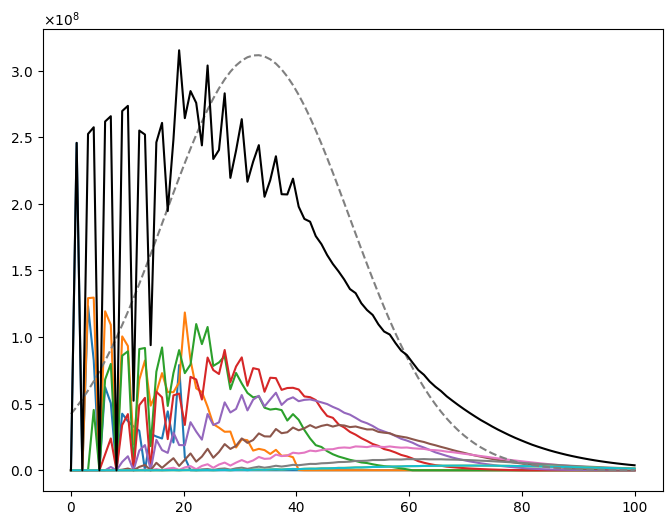

In [ ]:
# copied and pasted from incoherent approx notebook


omega_dw = 8.194e-6
multplier = 2.5
q_value  = multplier*np.sqrt(2*26161e3*13.124e-6) # uses averaged omega (not inverse of averaged inverse)


nLattice = 1000
test = StructureFactor1D_NIndepDW(nLattice = nLattice,q_value=q_value, couplingConst=28,)
fmt = ['r-', 'g-', 'b-', 'y-', 'c-']
max_omega = 150*1e-6 # keV
xlist, delta_omega = np.linspace(0, max_omega,50, retstep=True) 
nPhonon = 40


# impulse approx
deltasq = q_value**2 * 13.124e-6/(2*test.mass)
ia =  28**2 / (8/(test.latticeConst**3)) * np.sqrt(2*np.pi/deltasq) * np.exp(- (xlist-(q_value**2/(2*test.mass)))**2 / (2*deltasq)) # uses averaged omega (not inverse of averaged inverse)

sum = np.zeros(xlist.shape)
fig, ax = plt.subplots(figsize=(8,6))
test.setup_DoS(max_omega, nBins=2000)
test.init_recursion()
for i in range(1,nPhonon):
    s_diag = test.get_binned_s_diag(xlist, delta_omega) # get the binned s factor of order i
    s_diag = np.nan_to_num(s_diag, nan=0.0) # cleaning up the nan
    sum += s_diag # update the sum of s factor
    print(f'Plotting n = {i}...')
    # plot the current s factor
    ax.plot(xlist*1e6, s_diag,label=f'n = {i}') 
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((8,8))
    ax.yaxis.set_major_formatter(formatter)
    # calculate the s factor of next order
    test.update_s_factor()
# plotting the last s factor
print(f'Plotting n = {nPhonon}...')
ax.plot(xlist*1e6, s_diag,label=f'n = {nPhonon}')
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((8,8))
ax.yaxis.set_major_formatter(formatter)
# plot the impulse approximation
ax.plot(xlist*1e6, ia, linestyle="--", color="gray", label='Impulse')
# plot the sum of s for all orders
ax.plot(xlist*1e6,sum, label="Total",color="black")
# labels & titles
txt1 = r"$\omega_{DW}$" #r"exp$(\frac{q^2}{4m\omega_{DW}})$"
txt2 = r"$\sqrt{2m\bar\omega}$" 
plt.ylim(-0.1e8, 7.2e8)
plt.title(f'DoS + Incoherent approx, N-independent DW, Recursive\nN = {nLattice}, {txt1} = {omega_dw*1e6} meV, q = {multplier}{txt2}')# , {txt} = {test.omegaNaught*1e6} meV
plt.ylabel('Structure factor')
plt.xlabel(r'$\omega$[meV]')
# plt.legend()
# plt.savefig(f"sfactorwrtomega_q{int(q_value)}_{nLattice}lattice_NindepDW_energyCut_recur_DoS", bbox_inches="tight")